# Download Landsat AOI Clips with STAC

Search Landsat Collection 2 Level 2 scenes from the Microsoft Planetary Computer STAC API, download AOI-clipped bands, build cloud-masked mosaics, and accept the imagery only when the AOI coverage gate passes.

## Coverage Strategy

A single Landsat scene may not cover the whole AOI, and a low-cloud scene can still have clouds over the AOI. This notebook therefore does not assume coverage from scene metadata alone. It downloads all matching scenes, masks cloudy pixels with `qa_pixel`, mosaics clear pixels across scenes, and then checks the final mosaic coverage inside the AOI.

The final imagery is considered usable only when every checked spectral band reaches `COVERAGE_TARGET_PCT`. The default target is 99.9 percent AOI coverage, which allows tiny raster-edge/no-data slivers from reprojection while still rejecting meaningful AOI gaps. If the gate fails, widen `DATE_RANGE`, relax `MAX_CLOUD_COVER`, or add more scenes, then rerun the download/mosaic/coverage steps.

## Workflow

1. **Import packages and project paths.** This makes the notebook work from either the project root or the `notebooks/` folder and gives access to shared path constants and Landsat helper functions.

2. **Set the download and acceptance parameters.** We define the AOI file, STAC endpoint, Landsat collection, date range, maximum cloud cover, raster bands, output folders, download switches, cloud-mask switch, and AOI coverage target.

3. **Load the AOI boundary.** The exported dissolved AOI GeoJSON is read with GeoPandas and converted to EPSG:4326 because STAC spatial search expects lon/lat geometry.

4. **Search Landsat scenes with STAC.** The notebook queries `landsat-c2-l2` scenes intersecting the AOI, inside the date window, and with cloud cover below `MAX_CLOUD_COVER`.

5. **Review the scene table.** We turn STAC item metadata into a table so we can check dates, platforms, WRS path/row, and scene-level cloud cover before downloading any rasters.

6. **Select scenes to download.** The notebook selects all scenes returned by the STAC search, so all scenes with cloud cover below the threshold are included. This improves the chance of full clear-pixel AOI coverage.

7. **Clip raster assets to the AOI.** For each selected scene and band, the notebook signs the Planetary Computer asset URL, reads the raster, masks it to the AOI, and writes a compressed GeoTIFF clip. Remote tile reads can fail, so each band is retried with a fresh signed URL, written to a temporary `.part` file first, and existing completed clips are skipped on rerun. A progress loader shows total clips, new downloads, existing skipped clips, failures, and clips left.

8. **Cloud-mask and mosaic downloaded raster clips.** For spectral bands, `qa_pixel` masks fill, cloud, cirrus, and cloud-shadow pixels before mosaicking. The mosaic then fills cloudy gaps with clear pixels from other scenes where available and clips the result back to the AOI.

9. **Check AOI coverage.** The notebook reports the percent of AOI pixels with valid data for each mosaic band and applies the coverage gate. If coverage is below `COVERAGE_TARGET_PCT`, the workflow is not accepted.

10. **Write a manifest.** A JSON manifest records the STAC source, filter settings, selected scene IDs, bands, AOI path, files written, mosaics, cloud-mask setting, and coverage results so the download can be audited later.

Keep `RUN_DOWNLOAD = False` until you have reviewed the scene table and selected IDs. Set `RUN_DOWNLOAD = True` when you are ready to write raster clips, then set `RUN_MOSAIC = True` to build the cloud-masked band mosaics. Keep `qa_pixel` in `BANDS`; the cloud-mask step depends on it. `MOSAIC_BANDS` is spectral-only so the notebook does not waste disk space building a final QA mosaic. Keep `REQUIRE_FULL_COVERAGE = True` when you want the notebook to fail loudly if the final imagery does not cover the full AOI.


In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import importlib
import erw_mrv.landsat as landsat_module
importlib.reload(landsat_module)

from erw_mrv.landsat import (
    DEFAULT_COVERAGE_TARGET_PCT,
    DEFAULT_MAX_CLOUD_COVER,
    DEFAULT_STAC_URL,
    LANDSAT_COLLECTION,
    DEFAULT_BANDS,
    SPECTRAL_BANDS,
    coverage_gaps,
    coverage_is_complete,
    download_scene_bands,
    items_from_ids,
    load_aoi,
    mosaic_coverage_dataframe,
    mosaic_downloaded_bands,
    require_coverage,
    scenes_dataframe,
    search_landsat_items,
    select_all_scene_ids,
    write_manifest,
)
from erw_mrv.paths import BOUNDARIES_PROCESSED, LANDSAT_PROCESSED, LANDSAT_RAW, ensure_dir

pd.set_option("display.max_colwidth", 140)


## Settings

The settings below control both discovery and acceptance. `MAX_CLOUD_COVER` filters scenes before download; `COVERAGE_TARGET_PCT` evaluates the final mosaics after cloud masking. Full AOI coverage is verified at the mosaic stage, not assumed from scene cloud metadata.


In [2]:
AOI_PATH = BOUNDARIES_PROCESSED / "selected_districts_aoi.geojson"
STAC_URL = DEFAULT_STAC_URL
COLLECTION = LANDSAT_COLLECTION

DATE_RANGE = "2026-01-01/2026-06-29"
MAX_CLOUD_COVER = DEFAULT_MAX_CLOUD_COVER
BANDS = DEFAULT_BANDS
MOSAIC_BANDS = SPECTRAL_BANDS

OUT_DIR = ensure_dir(LANDSAT_RAW / "stac_aoi_clips" / "202601_202606")
MOSAIC_DIR = ensure_dir(LANDSAT_PROCESSED / "mosaics" / "202601_202606")
RUN_DOWNLOAD = False #default is False
RUN_MOSAIC = True #default is False
APPLY_CLOUD_MASK = True
DOWNLOAD_RETRIES = 3
DOWNLOAD_RETRY_DELAY = 5
SHOW_DOWNLOAD_PROGRESS = True
COVERAGE_TARGET_PCT = DEFAULT_COVERAGE_TARGET_PCT
REQUIRE_FULL_COVERAGE = True

AOI_PATH, OUT_DIR, MOSAIC_DIR


(PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/boundaries/selected_districts_aoi.geojson'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_raw/landsat/stac_aoi_clips/202601_202606'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606'))

## Load AOI

AOI features: 1
AOI geometry type: Polygon
AOI bbox: (np.float64(30.39649360400017), np.float64(0.162062292999963), np.float64(32.21209638100004), np.float64(2.301767055000084))


<Axes: >

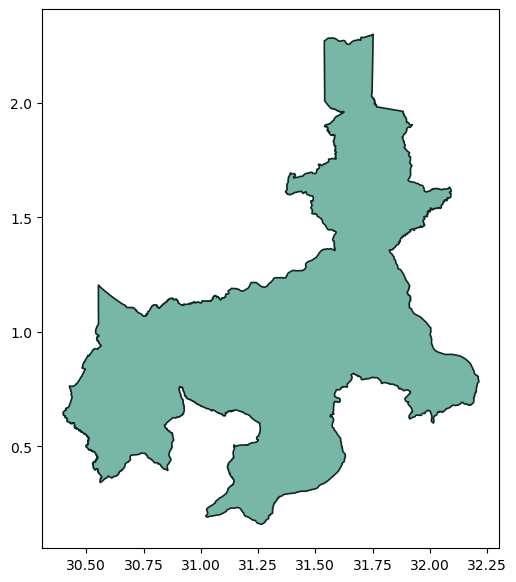

In [3]:
aoi, aoi_geojson = load_aoi(AOI_PATH)
aoi_union = aoi.geometry.union_all()
aoi_bbox = tuple(aoi.total_bounds)

print(f"AOI features: {len(aoi)}")
print(f"AOI geometry type: {aoi_union.geom_type}")
print(f"AOI bbox: {aoi_bbox}")
aoi.plot(figsize=(7, 7), facecolor="#78b7a7", edgecolor="#102820", linewidth=1.2)

## Search Landsat STAC Items

In [4]:
items = search_landsat_items(
    aoi_geojson=aoi_geojson,
    date_range=DATE_RANGE,
    max_cloud_cover=MAX_CLOUD_COVER,
    stac_url=STAC_URL,
    collection=COLLECTION,
    max_items=None,
)
print(f"Found {len(items)} Landsat scenes")

Found 32 Landsat scenes


In [5]:
scenes = scenes_dataframe(items)
scenes

,item_id,datetime,platform,cloud_cover,path,row,asset_count
0,LC08_L2SP_173059_20260106_02_T1,2026-01-06T08:13:24.276529Z,landsat-8,9.03,173,059,25
1,LC09_L2SP_172058_20260107_02_T1,2026-01-07T08:07:01.350577Z,landsat-9,0.10,172,058,25
2,LC09_L2SP_172059_20260107_02_T1,2026-01-07T08:07:25.267007Z,landsat-9,0.39,172,059,25
3,LC09_L2SP_172060_20260107_02_T1,2026-01-07T08:07:49.187676Z,landsat-9,8.45,172,060,25
4,LC08_L2SP_171059_20260108_02_T1,2026-01-08T08:01:01.112066Z,landsat-8,2.74,171,059,25
5,LC09_L2SP_173059_20260114_02_T1,2026-01-14T08:13:36.866685Z,landsat-9,1.63,173,059,25
6,LC09_L2SP_173060_20260114_02_T1,2026-01-14T08:14:00.778881Z,landsat-9,7.28,173,060,25
7,LC08_L2SP_172058_20260115_02_T1,2026-01-15T08:06:50.491295Z,landsat-8,0.00,172,058,25
8,LC08_L2SP_172059_20260115_02_T1,2026-01-15T08:07:14.407753Z,landsat-8,0.00,172,059,25
9,LC08_L2SP_172060_20260115_02_T1,2026-01-15T08:07:38.319973Z,landsat-8,0.00,172,060,25


## Pick Scenes to Download

Use every scene returned by the STAC search. The search already filters by AOI, date range, and `MAX_CLOUD_COVER`.

In [6]:
selected_item_ids = select_all_scene_ids(scenes)
selected_items = items_from_ids(items, selected_item_ids)

print(f"Selected {len(selected_items)} scenes with cloud cover < {MAX_CLOUD_COVER}%")
selected_item_ids

Selected 32 scenes with cloud cover < 10%


['LC08_L2SP_173059_20260106_02_T1',
 'LC09_L2SP_172058_20260107_02_T1',
 'LC09_L2SP_172059_20260107_02_T1',
 'LC09_L2SP_172060_20260107_02_T1',
 'LC08_L2SP_171059_20260108_02_T1',
 'LC09_L2SP_173059_20260114_02_T1',
 'LC09_L2SP_173060_20260114_02_T1',
 'LC08_L2SP_172058_20260115_02_T1',
 'LC08_L2SP_172059_20260115_02_T1',
 'LC08_L2SP_172060_20260115_02_T1',
 'LC09_L2SP_171059_20260116_02_T1',
 'LC09_L2SP_171060_20260116_02_T1',
 'LC09_L2SP_172058_20260123_02_T1',
 'LC09_L2SP_172059_20260123_02_T1',
 'LC09_L2SP_172060_20260123_02_T1',
 'LC08_L2SP_171059_20260124_02_T1',
 'LC09_L2SP_173059_20260215_02_T1',
 'LC09_L2SP_172058_20260224_02_T1',
 'LC09_L2SP_172059_20260224_02_T1',
 'LC09_L2SP_172058_20260312_02_T1',
 'LC08_L2SP_171059_20260329_02_T1',
 'LC09_L2SP_172058_20260413_02_T1',
 'LC08_L2SP_171059_20260414_02_T1',
 'LC09_L2SP_173059_20260506_02_T1',
 'LC09_L2SP_173059_20260522_02_T1',
 'LC09_L2SP_173060_20260522_02_T1',
 'LC09_L2SP_171059_20260524_02_T1',
 'LC09_L2SP_171060_20260524_

## Clip and Save AOI Bands

In [7]:
# Raster clipping is implemented in src/erw_mrv/landsat.py as download_scene_bands(...).

In [8]:
written = []

if RUN_DOWNLOAD:
    written = download_scene_bands(
        selected_items,
        BANDS,
        aoi,
        OUT_DIR,
        max_retries=DOWNLOAD_RETRIES,
        retry_delay=DOWNLOAD_RETRY_DELAY,
        show_progress=SHOW_DOWNLOAD_PROGRESS,
    )
else:
    print("Set RUN_DOWNLOAD = True after reviewing `scenes` and `selected_item_ids`.")

len(written)

Set RUN_DOWNLOAD = True after reviewing `scenes` and `selected_item_ids`.


0

## Cloud-Mask and Mosaic Downloaded Band Clips

This creates one AOI-clipped mosaic per band from all downloaded scene clips. For spectral bands, `qa_pixel` is used to mask fill, cloud, cirrus, and cloud-shadow pixels before merging scenes. This is the step that tries to fill cloudy gaps with clear observations from other dates or path/rows.


In [9]:
mosaics = []

if RUN_MOSAIC:
    mosaics = mosaic_downloaded_bands(
        clip_dir=OUT_DIR,
        aoi=aoi,
        bands=MOSAIC_BANDS,
        output_dir=MOSAIC_DIR,
        method="first",
        apply_cloud_mask=APPLY_CLOUD_MASK,
    )
else:
    print("Set RUN_MOSAIC = True after the download clips exist in OUT_DIR.")

mosaics


Exists: landsat_blue_mosaic_aoi.tif
Exists: landsat_green_mosaic_aoi.tif
Exists: landsat_red_mosaic_aoi.tif
Exists: landsat_nir08_mosaic_aoi.tif
Exists: landsat_swir16_mosaic_aoi.tif
Exists: landsat_swir22_mosaic_aoi.tif


[PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_blue_mosaic_aoi.tif'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_green_mosaic_aoi.tif'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_red_mosaic_aoi.tif'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_nir08_mosaic_aoi.tif'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_swir16_mosaic_aoi.tif'),
 PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_swir22_mosai

## Check Mosaic AOI Coverage

This is the acceptance gate for the raster product. The table reports valid-data coverage inside the AOI for each mosaic band. If any checked spectral band is below `COVERAGE_TARGET_PCT`, the notebook raises an error when `REQUIRE_FULL_COVERAGE = True`. A value slightly below 100%, such as 99.93%, can be acceptable when all bands have the same coverage because that usually indicates raster-edge alignment rather than clouds. Larger or uneven gaps mean you should widen `DATE_RANGE`, relax `MAX_CLOUD_COVER`, download more scenes, and rerun the cloud-masked mosaic.


In [10]:
coverage = mosaic_coverage_dataframe(mosaics, aoi) if mosaics else pd.DataFrame()
coverage_gaps_df = coverage_gaps(coverage, COVERAGE_TARGET_PCT) if not coverage.empty else pd.DataFrame()

if coverage.empty:
    print("No mosaics yet. Run the mosaic step before checking full AOI coverage.")
elif coverage_is_complete(coverage, COVERAGE_TARGET_PCT):
    print(f"Coverage gate passed: all checked bands meet >= {COVERAGE_TARGET_PCT}% AOI coverage.")
elif REQUIRE_FULL_COVERAGE:
    require_coverage(coverage, COVERAGE_TARGET_PCT)
else:
    print(f"Coverage gate failed: some bands are below {COVERAGE_TARGET_PCT}% AOI coverage.")

coverage

Coverage gate passed: all checked bands meet >= 99.9% AOI coverage.


,path,band,inside_aoi_pixels,valid_inside_aoi_pixels,valid_aoi_coverage_pct
0,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_blu...,blue,19339836,19326858,99.932895
1,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_gre...,green,19339836,19326858,99.932895
2,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_red...,red,19339836,19326858,99.932895
3,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_nir...,nir08,19339836,19326858,99.932895
4,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_swi...,swir16,19339836,19326858,99.932895
5,/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_processed/landsat/mosaics/202601_202606/landsat_swi...,swir22,19339836,19326858,99.932895


## Write Manifest

In [11]:
manifest_path = OUT_DIR / "landsat_stac_manifest.json"
manifest_path = write_manifest(
    manifest_path,
    stac_url=STAC_URL,
    collection=COLLECTION,
    date_range=DATE_RANGE,
    max_cloud_cover=MAX_CLOUD_COVER,
    aoi_path=AOI_PATH,
    bands=BANDS,
    selected_item_ids=selected_item_ids,
    written=written,
    mosaics=mosaics,
    apply_cloud_mask=APPLY_CLOUD_MASK,
    coverage_target_pct=COVERAGE_TARGET_PCT,
    coverage=coverage,
)
manifest_path

PosixPath('/Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data_raw/landsat/stac_aoi_clips/202601_202606/landsat_stac_manifest.json')

## Outputs From This Notebook

This notebook creates the January-June 2026 Landsat raster inputs used by the cropland workflow:

- `data_raw/landsat/stac_aoi_clips/202601_202606/{scene_id}_{band}_aoi.tif`: AOI-clipped Landsat scene bands downloaded from STAC.
- `data_raw/landsat/stac_aoi_clips/202601_202606/landsat_stac_manifest.json`: search, selection, download, mosaic, and coverage metadata.
- `data_processed/landsat/mosaics/202601_202606/landsat_{band}_mosaic_aoi.tif`: cloud-masked AOI mosaics for each requested band.
- `data_processed/landsat/mosaics/202601_202606/_cloud_masked_inputs/`: intermediate cloud-masked scene clips used to build mosaics.

Notebook `02_explore_cropland_mask.ipynb` expects the scene clips and final mosaics above. The imagery is only accepted when the coverage table passes the configured `COVERAGE_TARGET_PCT` gate.
